In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import sklearn 

In [3]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer 
from sklearn.preprocessing import StandardScaler , OneHotEncoder , QuantileTransformer


LOADING DATASET

In [89]:
df = pd.read_csv("titanic.csv")

Exploring Data

In [47]:
# df.head()
# df.info()
# df.describe()
# df.shape
df.isna().sum().sort_values(ascending=False)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
log_fare       0
dtype: int64

CLEANING DATA

In [ ]:
df = df.drop('deck' , axis =1)
df = df.drop('log_age' , axis=1)

df['embarked'].fillna(df['embarked'].mode()[0] , inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0] , inplace=True)
num_col = df.select_dtypes(include=['int64','float64']).columns
imputer = IterativeImputer(max_iter=10, random_state =42)
df[num_col] = imputer.fit_transform(df[num_col])


Handling Outliers

IQR METHOD

In [ ]:
# Age Outliers
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3-q1

lower_bond = q1 - 1.5*iqr
upper_bond = q3 + 1.5*iqr

df = df[(df['age']>=lower_bond) & (df['age']<=upper_bond)]

# Fare Outliers
q1 = df['fare'].quantile(0.25)
q3 = df['fare'].quantile(0.75)
iqr = q3-q1

lower_bond = q1 - 1.5*iqr
upper_bond = q3 + 1.5*iqr

df = df[(df['fare']>=lower_bond) & (df['fare']<=upper_bond)]
df['log_fare'] = np.log(df['fare'])




<Axes: xlabel='log_fare'>

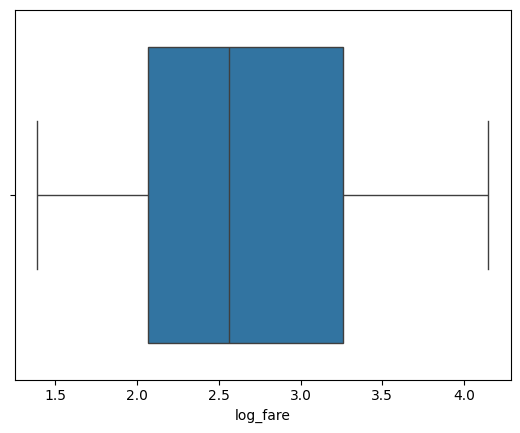

In [48]:
sns.boxplot(x=df['log_fare'])

<Axes: xlabel='age'>

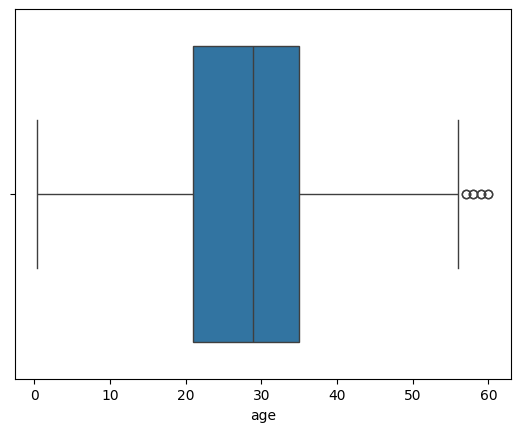

In [50]:
sns.boxplot(x=df['age'])

SCALING

In [98]:
num_col = df.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[num_col])
df[num_col]=scaler.inverse_transform(scaled_data)

In [59]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'log_fare'],
      dtype='object')

ENCODING

In [64]:
cat_cols = ['sex','embarked']

encoder = OneHotEncoder(drop='first' , sparse_output=False)
encoded_data = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols))
df = df.drop(columns=cat_cols)
df = pd.concat([df.reset_index(drop=True), encoded_df.reset_index(drop=True)] , axis=1)

In [99]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,-0.789272,0.827377,male,-0.530377,0.432793,-0.473674,-0.502445,S,Third,man,True,NaN,Southampton,no,False
1,1.266990,-1.566107,female,0.571831,0.432793,-0.473674,0.786845,C,First,woman,False,C,Cherbourg,yes,False
2,1.266990,0.827377,female,-0.254825,-0.474545,-0.473674,-0.488854,S,Third,woman,False,NaN,Southampton,yes,True
3,1.266990,-1.566107,female,0.365167,0.432793,-0.473674,0.420730,S,First,woman,False,C,Southampton,yes,False
4,-0.789272,0.827377,male,0.365167,-0.474545,-0.473674,-0.486337,S,Third,man,True,NaN,Southampton,no,True


Before Quantile Transformation

<Axes: xlabel='fare', ylabel='Count'>

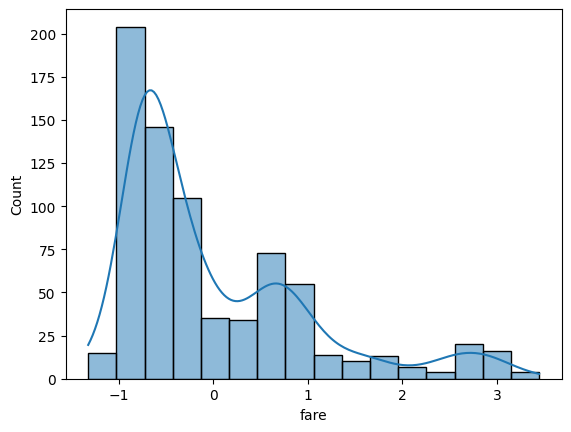

In [66]:
sns.histplot(x=df['fare'] , kde=True)

After Quantile Transformation

In [69]:
qt = QuantileTransformer(output_distribution='normal' , random_state=42)
df['fare']=qt.fit_transform(df[['fare']])

c:\adeelrana\envs\practiceproject\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (755). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: xlabel='fare', ylabel='Count'>

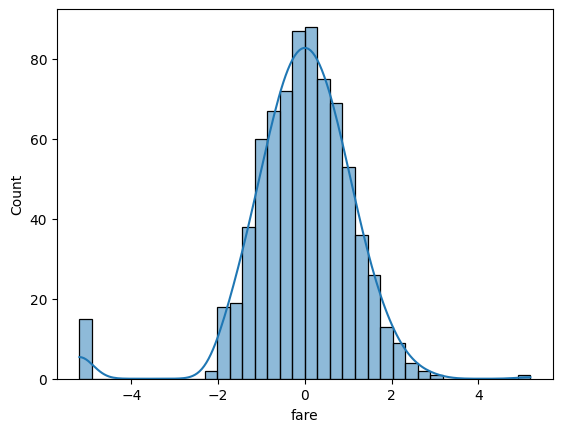

In [70]:
sns.histplot(x=df['fare'] , kde=True)

Before Quantile Tranformation

<Axes: xlabel='age', ylabel='Count'>

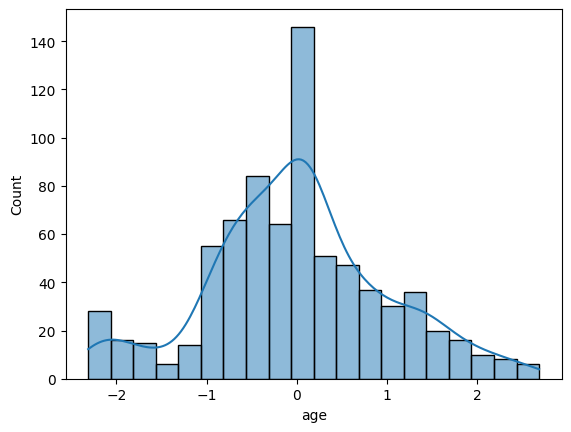

In [71]:
sns.histplot(x=df['age'] , kde=True)

After Quantile Transformation

In [72]:
qt = QuantileTransformer(output_distribution='normal' , random_state=42)
df['age']=qt.fit_transform(df[['age']])

c:\adeelrana\envs\practiceproject\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (755). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: xlabel='age', ylabel='Count'>

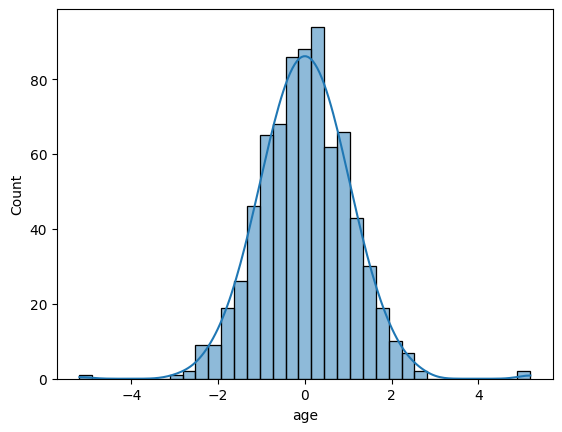

In [73]:
sns.histplot(x=df['age'], kde=True)